In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import numpy as np

In [41]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/NDVI_vegetated_MOD13Q1.nc'

ds = xr.open_dataset(ndvi_path)

ndvi = ds['NDVI_vegetated']

ndvi_sub = ndvi.copy()

/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


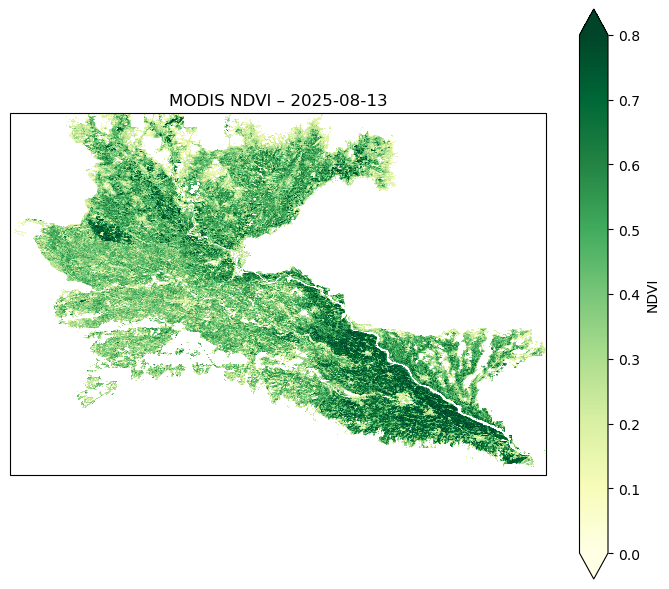

In [47]:
ndvi_map = ndvi.sel(time='2025-08-13')

fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ndvi_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.8,
    cbar_kwargs={'label': 'NDVI'}
)

ax.coastlines()
ax.set_title('MODIS NDVI – 2025-08-13')
plt.tight_layout()
plt.show()

In [30]:
ndvi_sub['time'] = pd.to_datetime([
    pd.Timestamp(t.year, t.month, t.day)
    for t in ndvi_sub['time'].values
])

In [32]:
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt'

snow = pd.read_csv(snow_path,
    sep=';',
    header=None,
    engine='python'
)

snow.columns = ['Year', 'Day', 'Snow_Mean', 'Snow_Percent','nn']
snow['Snow_Mean'] = snow['Snow_Mean'].replace(-9, pd.NA)

snow['Date'] = pd.to_datetime(
    snow['Year'].astype(int).astype(str),
    format='%Y'
) + pd.to_timedelta(snow['Day'] - 1, unit='D')

snow_df = snow[['Date', 'Snow_Percent']]
snow_df

,Date,Snow_Percent
0,2000-02-26,54.58
1,2000-02-27,55.93
2,2000-02-28,56.73
3,2000-02-29,56.78
4,2000-03-01,56.29
...,...,...
9245,2025-06-20,6.18
9246,2025-06-21,8.12
9247,2025-06-22,5.59
9248,2025-06-23,6.48


In [33]:
snow_df = snow_df.copy()
snow_df['Date'] = pd.to_datetime(snow_df['Date'])

snow_series = (
    snow_df
    .set_index('Date')['Snow_Percent']
    .reindex(ndvi['time'].values)
)

# Keep only dates where snow exists
valid_mask = ~snow_series.isna()

ndvi_sub = ndvi.isel(time=np.where(valid_mask)[0])
snow_vals = snow_series[valid_mask].values


In [43]:
ndvi_vals = ndvi_sub.values  # (time, lat, lon)
t, ny, nx = ndvi_vals.shape

# Flatten spatial dimensions
ndvi_2d = ndvi_vals.reshape(t, ny * nx)

# Standardise NDVI per pixel
ndvi_mean = np.nanmean(ndvi_2d, axis=0)
ndvi_std = np.nanstd(ndvi_2d, axis=0)
ndvi_std[ndvi_std == 0] = np.nan

ndvi_norm = (ndvi_2d - ndvi_mean) / ndvi_std

# Standardise snow
snow_norm = (snow_vals - np.nanmean(snow_vals)) / np.nanstd(snow_vals)

# Correlation
corr_flat = np.nanmean(ndvi_norm * snow_norm[:, None], axis=0)

# Back to map
corr_map = corr_flat.reshape(ny, nx)

/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_14757/21968949.py:8: RuntimeWarning: Mean of empty slice
  ndvi_mean = np.nanmean(ndvi_2d, axis=0)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_14757/21968949.py:15: RuntimeWarning: Mean of empty slice
  snow_norm = (snow_vals - np.nanmean(snow_vals)) / np.nanstd(snow_vals)


ValueError: operands could not be broadcast together with shapes (588,1730681) (0,1) 

In [46]:
ndvi_norm

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(588, 1730681))

In [42]:
ndvi_sub

<xarray.DataArray 'NDVI_vegetated' (time: 588, lat: 1081, lon: 1601)> Size: 8GB
[1017640428 values with dtype=float64]
Coordinates:
  * time     (time) object 5kB 2000-02-18 00:00:00 ... 2025-08-29 00:00:00
  * lat      (lat) float64 9kB 43.33 43.33 43.33 43.33 ... 41.09 41.09 41.08
  * lon      (lon) float64 13kB 58.17 58.17 58.17 58.17 ... 61.49 61.5 61.5 61.5
Attributes:
    description:           MOD13Q1 NDVI time series for vegetated pixels only...
    vegetation_threshold:  0.2

In [39]:
ny = ndvi_sub.shape[1]  # number of lat points
nx = ndvi_sub.shape[2]  # number of lon points

print(ndvi_sub.shape)  # (time, ny, nx)


(0, 1, 1)


In [35]:
corr_map = corr_flat.reshape(ny, nx)


ValueError: cannot reshape array of size 1 into shape (1081,1601)

In [37]:
corr_da = xr.DataArray(
    corr_map,
    coords={
        'lat': ndvi_sub.lat,
        'lon': ndvi_sub.lon
    },
    dims=['lat', 'lon'],
    name='ndvi_snow_corr'
)

CoordinateValidationError: conflicting sizes for dimension 'lat': length 1 on the data but length 1081 on coordinate 'lat'

In [38]:
corr_da = xr.DataArray(
    corr_map,
    coords={
        'lat': ndvi_sub.lat,
        'lon': ndvi_sub.lon
    },
    dims=['lat', 'lon'],
    name='ndvi_snow_corr'
)

CoordinateValidationError: conflicting sizes for dimension 'lat': length 1 on the data but length 1081 on coordinate 'lat'

-0.5713958769899619 -0.3443572091763933


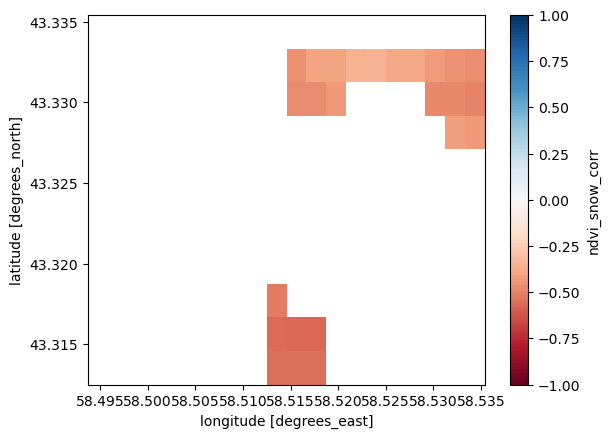

In [ ]:
print(np.nanmin(corr_map), np.nanmax(corr_map))

corr_da.plot(cmap='RdBu', vmin=-1, vmax=1)
